In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
sns.set_palette('viridis')
import random

In [2]:
df = pd.read_csv('assets\gender_classification_v7.csv')

In [3]:
df.sample(5)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
3180,1,12.5,6.5,1,1,1,1,Male
2124,1,13.6,5.2,1,1,1,1,Male
152,1,13.4,6.4,1,1,1,1,Male
2151,1,14.0,6.1,0,0,0,0,Female
580,1,13.4,6.4,0,0,0,0,Female


In [4]:
print(f"Columns = {df.shape[1]}\nRows = {df.shape[0]}")

Columns = 8
Rows = 5001


In [5]:
df.rename(columns={'forehead_width_cm':'forehead_width',
                   'forehead_height_cm':'forehead_height',
                   'distance_nose_to_lip_long':'dist_nose-lip'},inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   long_hair        5001 non-null   int64  
 1   forehead_width   5001 non-null   float64
 2   forehead_height  5001 non-null   float64
 3   nose_wide        5001 non-null   int64  
 4   nose_long        5001 non-null   int64  
 5   lips_thin        5001 non-null   int64  
 6   dist_nose-lip    5001 non-null   int64  
 7   gender           5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [7]:
print(f"Number of Duplicated values = {df.duplicated().sum()}")

Number of Duplicated values = 1768


In [8]:
print(f"Gender = {df.gender.unique()}")
print(f"Nose Wide = {df.nose_wide.unique()}")
print(f"Nose Long = {df.nose_long.unique()}")
print(f"Lips Thin = {df.lips_thin.unique()}")
print(f"Distance between Nose and Lips = {df['dist_nose-lip'].unique()}")


Gender = ['Male' 'Female']
Nose Wide = [1 0]
Nose Long = [0 1]
Lips Thin = [1 0]
Distance between Nose and Lips = [1 0]


Conclusion:
As the data is not that complicated. It is having categorical features more than the numerical one. Data flows the validation and consistency across it. No need to perform any type of sampling as the number of females and males are almost equal. But the biggest problem is that more than 34% of the data is duplicate. Which will make the model more bias and not good for the future prediction.

In [9]:
df.gender.value_counts()

gender
Female    2501
Male      2500
Name: count, dtype: int64

In [10]:
print("Average Forehead Width in both gender")
df.groupby('gender').forehead_width.mean()

Average Forehead Width in both gender


gender
Female    12.811675
Male      13.551440
Name: forehead_width, dtype: float64

In [11]:
print("Average Forehead Height in both gender")
df.groupby('gender').forehead_height.mean()

Average Forehead Height in both gender


gender
Female    5.796321
Male      6.096360
Name: forehead_height, dtype: float64

In [12]:
df.long_hair.count()

np.int64(5001)

In [13]:
print(f"Percentage of people having long hair {round(((df.long_hair[df.long_hair==1].count()/df.long_hair.count())*100),2)} %")

Percentage of people having long hair 86.96 %


In [14]:
df[(df.nose_long==1) & (df['dist_nose-lip']==1)]

,long_hair,forehead_width,forehead_height,nose_wide,nose_long,lips_thin,dist_nose-lip,gender
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
5,1,13.0,6.8,1,1,1,1,Male
10,0,12.5,5.4,1,1,1,1,Male
11,1,15.5,5.8,1,1,1,1,Male
...,...,...,...,...,...,...,...,...
4987,1,12.1,6.2,1,1,1,1,Male
4992,1,14.1,7.0,1,1,1,1,Male
4994,1,12.9,7.0,1,1,1,1,Male
4995,1,12.3,6.9,0,1,1,1,Male


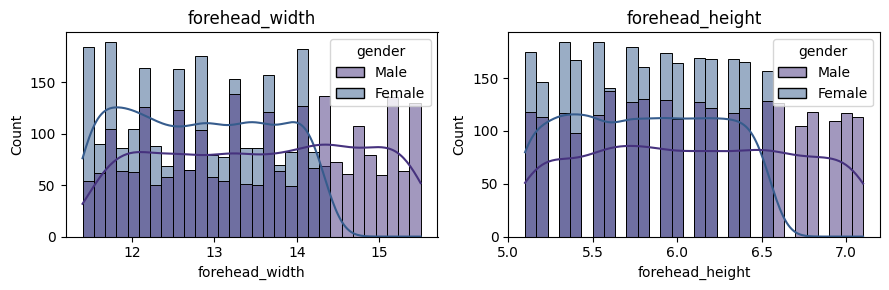

In [15]:
fig,ax=plt.subplots(1,2,figsize=(9,3))
ax=ax.flatten()
for i,cols in enumerate(df.select_dtypes('float')):
    sns.histplot(kde=True, data=df, x=cols,ax=ax[i],hue='gender',bins=30)
    ax[i].set_title(cols)
plt.tight_layout()
plt.show()

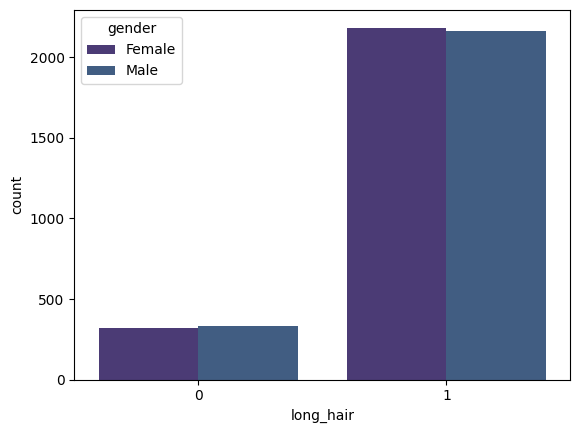

In [16]:
sns.countplot(data=df, x='long_hair', hue='gender')
plt.show()

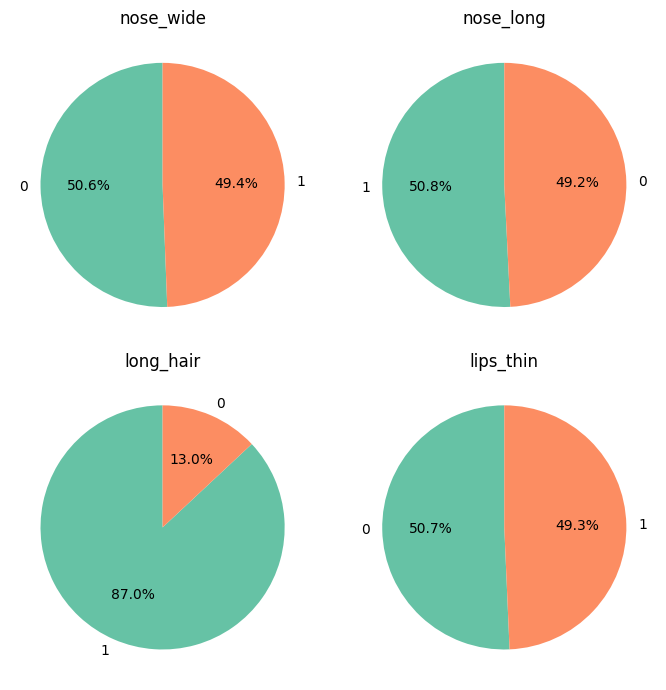

In [17]:
fig,ax=plt.subplots(2,2,figsize=(7,7))
ax=ax.flatten()


for i,cols in enumerate(['nose_wide','nose_long','long_hair','lips_thin']):
    counts=df[cols].value_counts()
    colors = sns.color_palette('Set2', len(counts))  
    ax[i].pie(counts,labels=counts.index,autopct='%1.1f%%',startangle=90,colors=colors)
    ax[i].set_title(cols)
plt.tight_layout()
plt.show()

In [18]:
tf=df.copy()
tf.replace({'Male':1, 'Female':0},inplace=True)

C:\Users\Sakshan Sharma\AppData\Local\Temp\ipykernel_20176\1752915747.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tf.replace({'Male':1, 'Female':0},inplace=True)


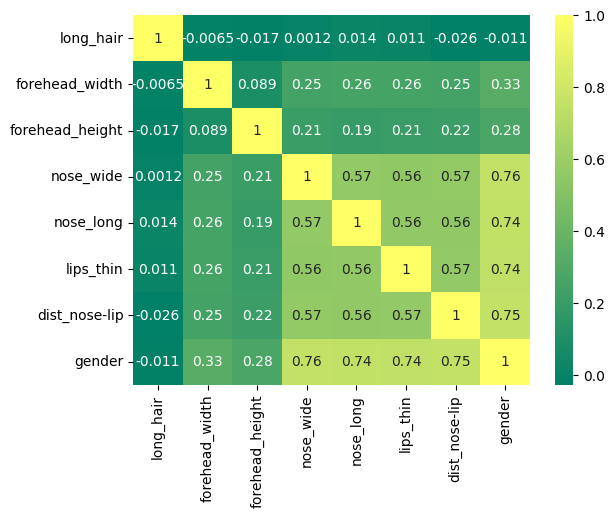

In [19]:
sns.heatmap(tf.corr(),annot=True,cmap='summer')
plt.show()

In [20]:
from sklearn.model_selection import GridSearchCV , train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import VotingClassifier , RandomForestClassifier , AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder , StandardScaler ,LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

In [21]:
X = df.iloc[:,:-1]
y=df['gender']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=43)
print(f"Training set size {X_train.shape[0]} and \nTesting set size {y_test.shape[0]}")

Training set size 4000 and 
Testing set size 1001


In [22]:
label=LabelEncoder()
y_train_trf=label.fit_transform(y_train)
y_test_trf=label.transform(y_test)


cols=ColumnTransformer(
    [
        ('std',StandardScaler(),['long_hair','forehead_width','forehead_height','nose_wide',
                                 'nose_long','lips_thin','dist_nose-lip'])
    ]
    ,remainder='passthrough'
)

In [23]:
pipeline = Pipeline(
    [
        ('preprocess',cols),
        ('model',LogisticRegression(max_iter=200))
    ]
)

In [24]:
pipeline.fit(X_train,y_train_trf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('std', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [25]:
colormaps = [
    'Blues', 'Reds', 'Greens', 'Purples', 'Oranges', 'Greys',
    'YlOrBr', 'YlOrRd', 'YlGn', 'YlGnBu', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
    'GnBu', 'PuBu', 'PuBuGn', 'BuGn', 'YlGnBu', 'coolwarm', 'viridis',
    'plasma', 'inferno', 'magma', 'cividis', 'cubehelix', 'Spectral',
    'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20',
    'Accent', 'Dark2', 'Paired', 'flag', 'prism', 'ocean', 'terrain',
    'gist_earth', 'gist_stern', 'gnuplot', 'gnuplot2', 'CMRmap', 'cubehelix'
]

In [26]:
def predictions(obj):
    y_score = obj.predict(X_test)
    print(f"Accuracy Score {round((accuracy_score(y_true=y_test_trf,y_pred=y_score)),2)*100} %")
    print()
    print()
    fig,ax = plt.subplots(1,2,figsize=(11,4))
    ax = ax.flatten()
    cmap_choice = random.choice(colormaps)
    sns.heatmap(confusion_matrix(y_true=y_test_trf,y_pred=y_score),cmap=cmap_choice,annot=True,ax=ax[0])
    ax[1].set_title("Confusion Matrix")
    y_score_proba = obj.predict_proba(X_test)[:,1]
    fpr,tpr,threshold = roc_curve(y_true=y_test_trf, y_score=y_score_proba)
    ax[1].plot(fpr,tpr)
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].set_title("Roc Curve")
    plt.show()

Accuracy Score 97.0 %




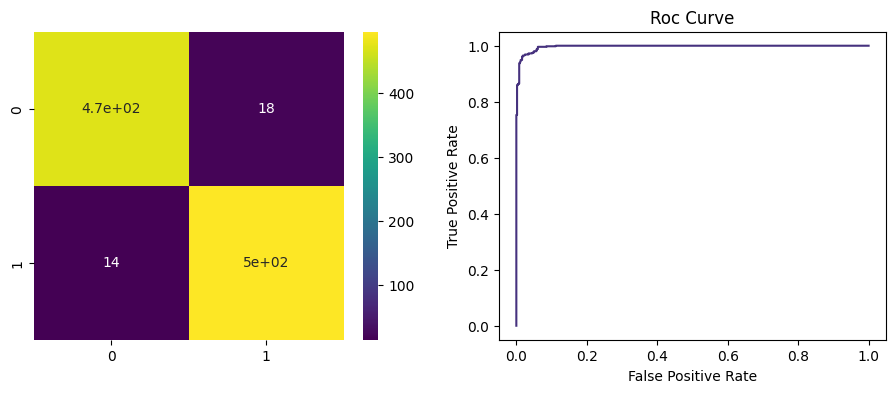

In [27]:
predictions(pipeline)

In [28]:
pipeline2 = Pipeline(
    [
        ('preprocess',cols),
        ('model',KNeighborsClassifier(n_neighbors=4,metric='euclidean'))
    ]
)

In [29]:
pipeline2.fit(X_train, y_train_trf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('std', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

Accuracy Score 97.0 %




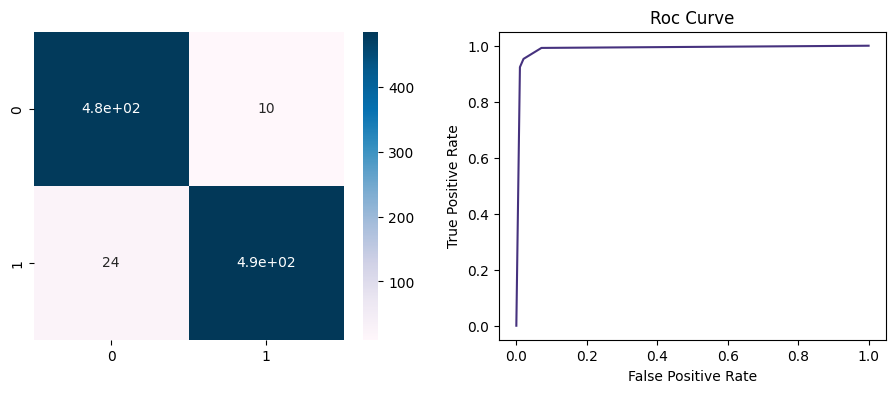

In [30]:
predictions(pipeline2)

Without any duplicated values

In [31]:
tf = df.copy()

In [32]:
tf.duplicated().sum()

np.int64(1768)

In [33]:
tf.drop_duplicates(inplace=True)

In [34]:
tf.shape

(3233, 8)

In [35]:
tf.duplicated().sum()

np.int64(0)

In [36]:
X=tf.iloc[:,:-1]
y=tf['gender']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)
print(f" Training Set is {X_train.shape[0]} and \n Testing is {y_test.shape[0]}")

 Training Set is 2586 and 
 Testing is 647


In [37]:
label = LabelEncoder()
y_train_trf = label.fit_transform(y_train)
y_test_trf = label.transform(y_test)

In [38]:
pipeline.fit(X_train,y_train_trf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('std', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

Accuracy Score 96.0 %




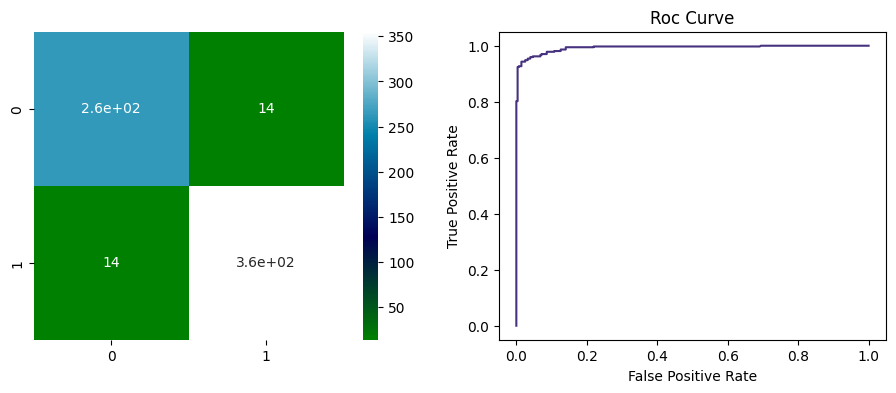

In [39]:
predictions(pipeline)

In [41]:
pipeline2.fit(X_train,y_train_trf)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('std', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

Accuracy Score 94.0 %




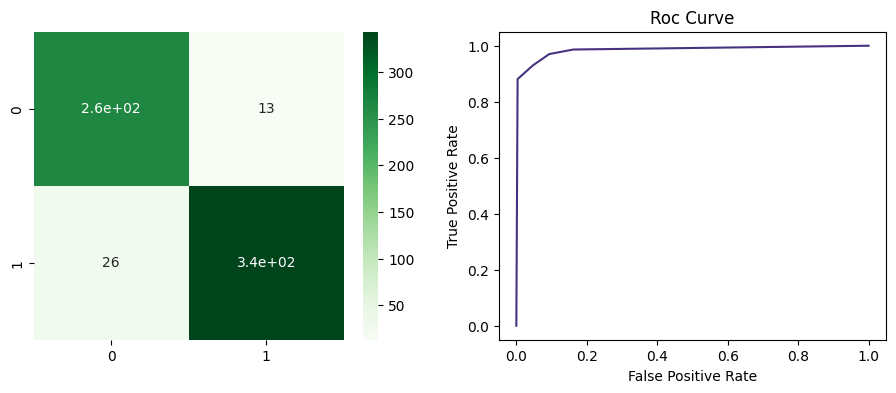

In [42]:
predictions(pipeline2)